<a href="https://colab.research.google.com/github/Bienbaz/Multiple-Linear-Regression/blob/main/multiple_regression_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Multiple Linear Regression – Multi-Channel Marketing Analysis

In [8]:
# Upload CSV in Google Colab
try:
    from google.colab import files
    uploaded = files.upload()
except:
    print("Place marketing_sales_data.csv in the notebook folder.")


Saving marketing_sales_data.csv to marketing_sales_data (1).csv


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
sns.set_style('whitegrid')


In [10]:
df = pd.read_csv('marketing_sales_data.csv')
display(df.head())
print(df.info())
print(df.isnull().sum())
print(df.describe())


,TV,Radio,Social Media,Influencer,Sales
0,Low,3.518070,2.293790,Micro,55.261284
1,Low,7.756876,2.572287,Mega,67.574904
2,High,20.348988,1.227180,Micro,272.250108
3,Medium,20.108487,2.728374,Mega,195.102176
4,High,31.653200,7.776978,Nano,273.960377


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 572 entries, 0 to 571
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   TV            572 non-null    object 
 1   Radio         572 non-null    float64
 2   Social Media  572 non-null    float64
 3   Influencer    572 non-null    object 
 4   Sales         572 non-null    float64
dtypes: float64(3), object(2)
memory usage: 22.5+ KB
None
TV              0
Radio           0
Social Media    0
Influencer      0
Sales           0
dtype: int64
            Radio  Social Media       Sales
count  572.000000    572.000000  572.000000
mean    17.520616      3.333803  189.296908
std      9.290933      2.238378   89.871581
min      0.109106      0.000031   33.509810
25%     10.699556      1.585549  118.718722
50%     17.149517      3.150111  184.005362
75%     24.606396      4.730408  264.500118
max     42.271579     11.403625  357.788195


In [11]:
df = df.dropna()
print('Shape:', df.shape)


Shape: (572, 5)


## Correlation Matrix

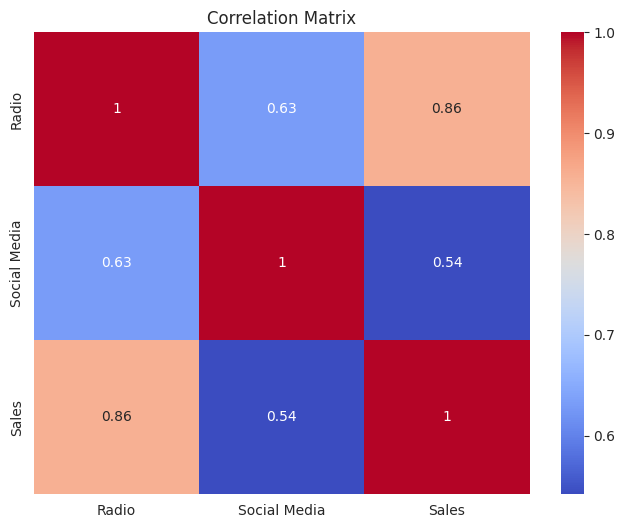

In [12]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()


## Multicollinearity Check (VIF)

In [17]:
features = ['TV','Radio','Social Media']
X_vif = df[features]

# One-hot encode the 'TV' column since it's categorical
X_vif = pd.get_dummies(X_vif, columns=['TV'], drop_first=True)

# Convert boolean columns to numeric (0 or 1) for VIF calculation
X_vif = X_vif.astype(float)

vif_df = pd.DataFrame()
vif_df['Feature'] = X_vif.columns
vif_df['VIF'] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]

print(vif_df)

        Feature       VIF
0         Radio  5.464372
1  Social Media  5.304131
2        TV_Low  1.138887
3     TV_Medium  1.443547


## Multiple Linear Regression

In [20]:
X = df[['TV','Radio','Social Media']]
y = df['Sales']

# One-hot encode the 'TV' column as it is categorical
X = pd.get_dummies(X, columns=['TV'], drop_first=True)

# Convert boolean columns to numeric (0 or 1) for OLS model
X = X.astype(float)

X = sm.add_constant(X)

model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.904
Model:                            OLS   Adj. R-squared:                  0.903
Method:                 Least Squares   F-statistic:                     1335.
Date:                Mon, 15 Jun 2026   Prob (F-statistic):          7.29e-287
Time:                        13:08:34   Log-Likelihood:                -2713.9
No. Observations:                 572   AIC:                             5438.
Df Residuals:                     567   BIC:                             5460.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const          218.6473      6.290     34.761   

In [21]:
print('Adjusted R-squared:', model.rsquared_adj)

coefficients = pd.DataFrame({
    'Variable': model.params.index,
    'Coefficient': model.params.values,
    'P_Value': model.pvalues.values
})

display(coefficients)


Adjusted R-squared: 0.9033396396227038


,Variable,Coefficient,P_Value
0,const,218.647300,1.192076e-142
1,Radio,2.989132,5.661677e-33
2,Social Media,-0.149951,8.237009e-01
3,TV_Low,-154.312057,1.518358e-125
4,TV_Medium,-75.327863,1.207701e-71


## Final Regression Equation

In [23]:
b_const = model.params['const']
b_radio = model.params['Radio']
b_social_media = model.params['Social Media']
b_tv_low = model.params['TV_Low']
b_tv_medium = model.params['TV_Medium']

print(f'Sales = {b_const:.4f} + ({b_radio:.4f}*Radio) + ({b_social_media:.4f}*Social Media) + ({b_tv_low:.4f}*TV_Low) + ({b_tv_medium:.4f}*TV_Medium)')

Sales = 218.6473 + (2.9891*Radio) + (-0.1500*Social Media) + (-154.3121*TV_Low) + (-75.3279*TV_Medium)


## Assumption Checking

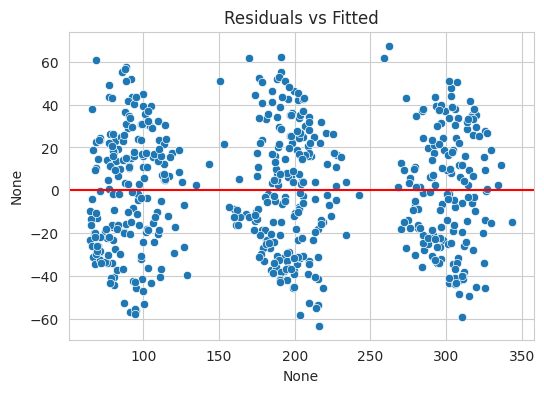

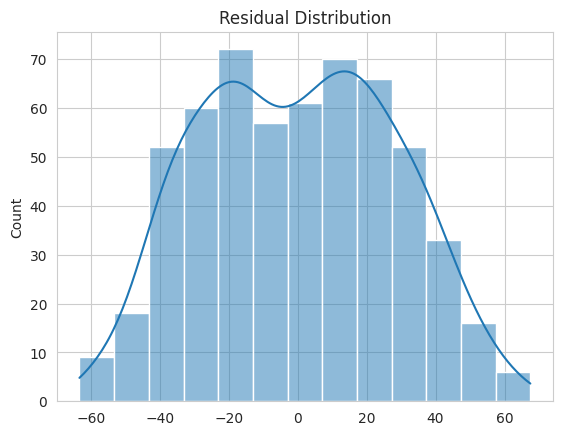

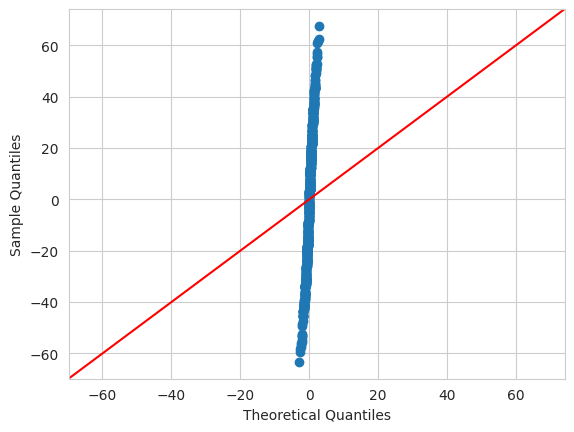

In [24]:
fitted = model.fittedvalues
residuals = model.resid

plt.figure(figsize=(6,4))
sns.scatterplot(x=fitted,y=residuals)
plt.axhline(y=0,color='red')
plt.title('Residuals vs Fitted')
plt.show()

sns.histplot(residuals,kde=True)
plt.title('Residual Distribution')
plt.show()

sm.qqplot(residuals,line='45')
plt.show()


## Business Interpretation

In [26]:
print('Coefficient Interpretation:')
for variable in ['Radio', 'Social Media', 'TV_Low', 'TV_Medium']:
    coef = model.params[variable]
    if 'TV_' in variable:
        print(f'Holding other channels constant, changing TV from High to {variable.replace("TV_", "")} changes Sales by {coef:.4f} units.')
    else:
        print(f'Holding other channels constant, a one-unit increase in {variable} spend changes Sales by {coef:.4f} units.')

print('\nRecommendation:')
print('Prioritize budget toward statistically significant channels with positive coefficients and low p-values.')

Coefficient Interpretation:
Holding other channels constant, a one-unit increase in Radio spend changes Sales by 2.9891 units.
Holding other channels constant, a one-unit increase in Social Media spend changes Sales by -0.1500 units.
Holding other channels constant, changing TV from High to Low changes Sales by -154.3121 units.
Holding other channels constant, changing TV from High to Medium changes Sales by -75.3279 units.

Recommendation:
Prioritize budget toward statistically significant channels with positive coefficients and low p-values.
